# CNN and CNN-LSTM: next-day LMT direction
This notebook compares a small CNN and CNN-LSTM. The target is whether the next trading day's close is above its open. Features are built from information available by the close of the current day. The models use the same calendar training, validation, and test periods as the original project. Run the cells from top to bottom.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

DATA_FILE = "final_data.csv"
TICKERS = ["lmt", "noc", "rtx", "spy", "qqq"]
VAL_START = pd.Timestamp("2024-09-26")
TEST_START = pd.Timestamp("2025-08-07")
TEST_END = pd.Timestamp("2026-04-10")
WINDOW = 60

tf.keras.utils.set_random_seed(42)

## Load and prepare data
Use log returns and rolling LMT momentum/volatility. The label is shifted to the next trading day. Missing values are filled and features are scaled using training data only.

In [2]:
data = pd.read_csv(DATA_FILE, parse_dates=["date"])
data = data.sort_values("date").drop_duplicates("date").reset_index(drop=True)

features = {}
for ticker in TICKERS:
    close = data[f"{ticker}_close"].clip(lower=1e-8)
    open_price = data[f"{ticker}_open"].clip(lower=1e-8)
    features[f"{ticker}_daily_return"] = np.log(close).diff()
    features[f"{ticker}_intraday_return"] = np.log(close / open_price)

lmt_return = features["lmt_daily_return"]
for length in [5, 20]:
    features[f"lmt_momentum_{length}"] = lmt_return.rolling(length).sum()
    features[f"lmt_volatility_{length}"] = lmt_return.rolling(length).std()
if "lmt_volume" in data:
    features["lmt_volume_change"] = np.log(data["lmt_volume"].clip(lower=1)).diff()

X = pd.DataFrame(features).replace([np.inf, -np.inf], np.nan)
next_day_change = data["lmt_close"].shift(-1) - data["lmt_open"].shift(-1)
valid = next_day_change.notna() & (data["date"] <= TEST_END)
X = X.loc[valid]
dates = data.loc[valid, "date"]
y = (next_day_change.loc[valid] > 0).astype(int).to_numpy()

train = (dates < VAL_START).to_numpy()
val = ((dates >= VAL_START) & (dates < TEST_START)).to_numpy()
test = ((dates >= TEST_START) & (dates <= TEST_END)).to_numpy()
if min(train.sum(), val.sum(), test.sum()) < WINDOW:
    raise ValueError("A chronological split has fewer days than the window")

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_train = scaler.fit_transform(imputer.fit_transform(X.loc[train]))
X_val = scaler.transform(imputer.transform(X.loc[val]))
X_test = scaler.transform(imputer.transform(X.loc[test]))
y_train, y_val, y_test = y[train], y[val], y[test]
print(f"Days: train={len(y_train)}, validation={len(y_val)}, test={len(y_test)}")
print(f"Features per day: {X_train.shape[1]}")

Days: train=787, validation=170, test=170
Features per day: 15


## Build 60-day sequences
Each sequence ends on the feature day. Its label describes the following trading day's open-to-close direction. Sequences are formed within each chronological split.

In [3]:
def create_sequences(X_values, labels, window):
    sequences = np.stack([
        X_values[i - window + 1:i + 1]
        for i in range(window - 1, len(labels))
    ])
    return sequences.astype("float32"), labels[window - 1:].astype("float32")

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, WINDOW)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, WINDOW)
print(f"Sequences: train={len(y_train_seq)}, validation={len(y_val_seq)}, test={len(y_test_seq)}")

Sequences: train=728, validation=111, test=111


## Define CNN and CNN-LSTM models
Both use a small causal 1D convolution. The second model adds an LSTM. Dropout and L2 regularization limit overfitting.

In [4]:
def build_model(kind, window, n_features):
    regularizer = tf.keras.regularizers.l2(0.001)
    inputs = tf.keras.Input(shape=(window, n_features))
    x = tf.keras.layers.Conv1D(16, 3, padding="causal", activation="relu",
                               kernel_regularizer=regularizer)(inputs)
    if kind == "CNN-LSTM":
        x = tf.keras.layers.LSTM(16, kernel_regularizer=regularizer)(x)
    else:
        x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

## Train and select using validation data
Training progress appears below this cell. Early stopping restores the weights with the lowest validation loss. The test set is evaluated only after selecting a model.

In [5]:
models = {}
histories = {}
validation_scores = {}

for name in ["CNN", "CNN-LSTM"]:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    model = build_model(name, WINDOW, X_train_seq.shape[-1])
    stopper = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    print(f"\nTraining {name}:")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=80, batch_size=32, callbacks=[stopper], verbose=1
    )
    val_prob = model.predict(X_val_seq, verbose=0).ravel()
    val_acc = accuracy_score(y_val_seq, val_prob >= 0.5)
    models[name] = model
    histories[name] = history.history
    validation_scores[name] = val_acc
    print(f"{name} validation accuracy: {val_acc:.3f}")

chosen = max(validation_scores, key=validation_scores.get)
print(f"\nSelected on validation: {chosen}")
pd.DataFrame({"Validation accuracy": validation_scores}).round(3)


Training CNN:
Epoch 1/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5220 - loss: 0.7321 - val_accuracy: 0.5405 - val_loss: 0.7063
Epoch 2/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5151 - loss: 0.7193 - val_accuracy: 0.5405 - val_loss: 0.7061
Epoch 3/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4931 - loss: 0.7178 - val_accuracy: 0.5405 - val_loss: 0.7055
Epoch 4/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5151 - loss: 0.7115 - val_accuracy: 0.5405 - val_loss: 0.7046
Epoch 5/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5206 - loss: 0.7109 - val_accuracy: 0.5405 - val_loss: 0.7044
Epoch 6/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5234 - loss: 0.7073 - val_accuracy: 0.5495 - val_loss: 0.7043
Epoch 7/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5453 - loss: 0.7037 - val_accuracy: 0.5135 - val_loss: 0.7043
Epoch 8/80
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5316 - loss: 0.7056 - val_accur

,Validation accuracy
CNN,0.532
CNN-LSTM,0.559


## Training curves
These show whether validation loss stops improving while training loss keeps falling.

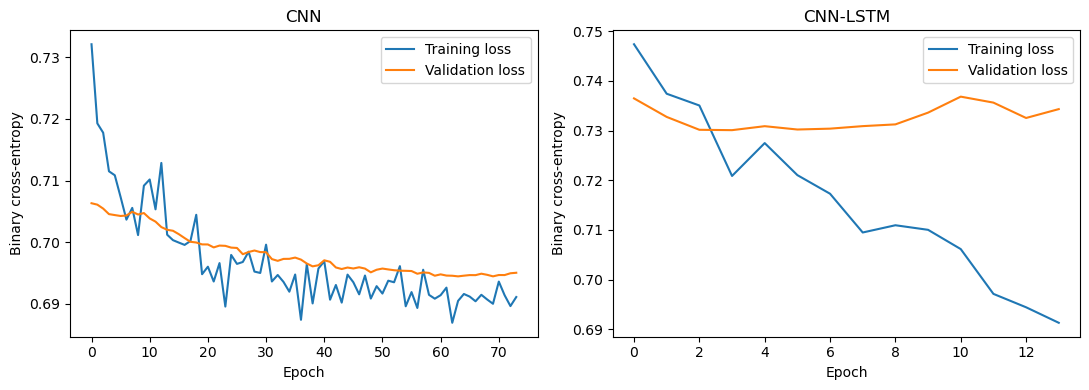

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ["CNN", "CNN-LSTM"]):
    ax.plot(histories[name]["loss"], label="Training loss")
    ax.plot(histories[name]["val_loss"], label="Validation loss")
    ax.set(title=name, xlabel="Epoch", ylabel="Binary cross-entropy")
    ax.legend()
plt.tight_layout()
plt.show()

## Held-out test results
Compare the selected network with a training-majority baseline on exactly the same test sequences. This is a small historical sample, so a few additional correct days do not establish a reliable future signal.

Selected model: CNN-LSTM
Test accuracy: 0.568
Balanced accuracy: 0.543
Training-majority test accuracy: 0.532


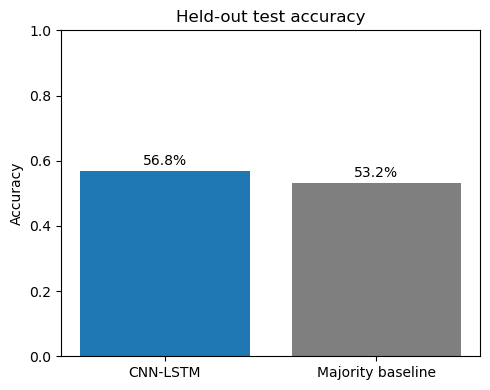

In [7]:
test_prob = models[chosen].predict(X_test_seq, verbose=0).ravel()
test_pred = (test_prob >= 0.5).astype(int)
majority_class = int(y_train_seq.mean() >= 0.5)
baseline_pred = np.full(len(y_test_seq), majority_class)

model_acc = accuracy_score(y_test_seq, test_pred)
baseline_acc = accuracy_score(y_test_seq, baseline_pred)
print(f"Selected model: {chosen}")
print(f"Test accuracy: {model_acc:.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_seq, test_pred):.3f}")
print(f"Training-majority test accuracy: {baseline_acc:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([chosen, "Majority baseline"], [model_acc, baseline_acc],
       color=["tab:blue", "tab:gray"])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Held-out test accuracy")
for i, value in enumerate([model_acc, baseline_acc]):
    ax.text(i, value + 0.02, f"{value:.1%}", ha="center")
plt.tight_layout()
plt.show()

## Confusion matrix
Rows are actual outcomes; columns are predicted outcomes. 0 means the next day's close did not exceed its open, and 1 means it did.

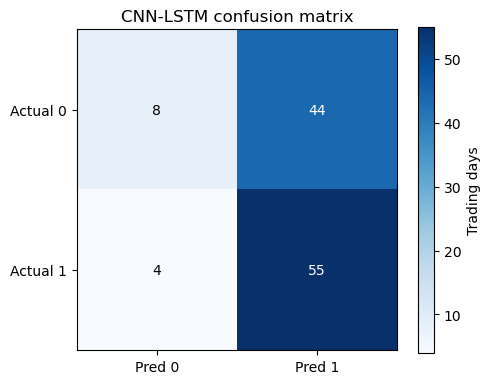

In [8]:
cm = confusion_matrix(y_test_seq, test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["Actual 0", "Actual 1"])
ax.set_title(f"{chosen} confusion matrix")
for row in range(2):
    for col in range(2):
        ax.text(col, row, cm[row, col], ha="center", va="center",
                color="white" if cm[row, col] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, label="Trading days")
plt.tight_layout()
plt.show()